# 一、创建AlexNet模型

In [22]:
import torch
from torch import nn
from torchsummary import summary


class AlexNet(nn.Module):
    def __init__(self, num_classes=1000):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, 11, 4, 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),
            nn.Conv2d(96, 256, 5, 1, 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),
            nn.Conv2d(256, 384, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, 2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


if __name__ == '__main__':
    model = AlexNet().to("cuda")
    print(summary(model, (3, 224, 224)))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 55, 55]          34,944
              ReLU-2           [-1, 96, 55, 55]               0
         MaxPool2d-3           [-1, 96, 27, 27]               0
            Conv2d-4          [-1, 256, 27, 27]         614,656
              ReLU-5          [-1, 256, 27, 27]               0
         MaxPool2d-6          [-1, 256, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         885,120
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 384, 13, 13]       1,327,488
             ReLU-10          [-1, 384, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         884,992
             ReLU-12          [-1, 256, 13, 13]               0
        MaxPool2d-13            [-1, 256, 6, 6]               0
          Dropout-14                 [-

# 二、加载数据集

In [23]:
# 导入所需的库
import os
import random

# 导入数据处理和可视化库
import matplotlib.pyplot as plt
import numpy as np

# 导入深度学习框架 PyTorch 相关库
import torch



# 设置随机种子以保证结果的可重复性
def setup_seed(seed):
    np.random.seed(seed)  # 设置 Numpy 随机种子
    random.seed(seed)  # 设置 Python 内置随机种子
    os.environ['PYTHONHASHSEED'] = str(seed)  # 设置 Python 哈希种子
    torch.manual_seed(seed)  # 设置 PyTorch 随机种子
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)  # 设置 CUDA 随机种子
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False  # 关闭 cudnn 加速
        torch.backends.cudnn.deterministic = True  # 设置 cudnn 为确定性算法


# 设置随机种子
setup_seed(0)
# 检查是否有可用的 GPU，如果有则使用 GPU，否则使用 CPU
if torch.cuda.is_available():
    device = torch.device("cuda")  # 使用 GPU
    print("CUDA is available. Using GPU.")
else:
    device = torch.device("cpu")  # 使用 CPU
    print("CUDA is not available. Using CPU.")

CUDA is available. Using GPU.


In [24]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
transform = {
    "train": transforms.Compose([transforms.RandomResizedCrop(224), transforms.ToTensor(),
                                 transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]),
    "test": transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                                 transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]),
}

train_dataset = datasets.ImageFolder("./dataset/dog_cat/train", transform=transform["train"])
test_dataset = datasets.ImageFolder("./dataset/dog_cat/test", transform=transform["test"])

print(train_dataset)
print(test_dataset)

Dataset ImageFolder
    Number of datapoints: 22500
    Root location: ./dataset/dog_cat/train
    StandardTransform
Transform: Compose(
               RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )
Dataset ImageFolder
    Number of datapoints: 2500
    Root location: ./dataset/dog_cat/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )


In [25]:
train_dataloader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1024, shuffle=False)
print(len(train_dataloader))
print(len(test_dataloader))

22
3


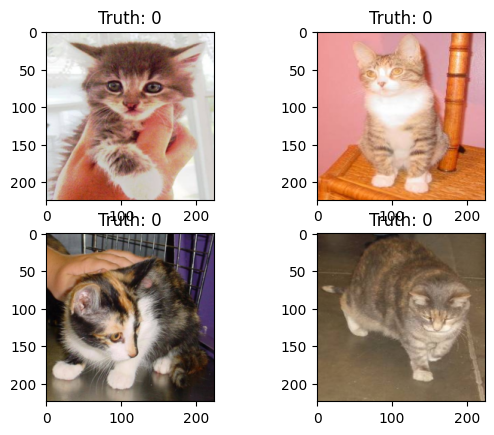

In [26]:
# 打印一下图片
examples = enumerate(test_dataloader)
batch_idx, (imgs, labels) = examples.__next__()
for i in range(4):
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    image = imgs[i].numpy() * std[:, None, None] + mean[:, None, None]
    # 将图片转成numpy数组，主要是转换通道和宽高位置
    image = np.transpose(image, (1, 2, 0))
    plt.subplot(2, 2, i+1)
    plt.imshow(image)
    plt.title(f"Truth: {labels[i]}")
plt.show()

# 三、训练模型

In [21]:
import time
model = AlexNet(num_classes=2).to(device)
cri = torch.nn.CrossEntropyLoss()
optomizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoches = 50
most_acc = 0
last_time = 0
for epoch in range(epoches):
    model.train()
    total_loss = 0
    for i, (images, labels) in enumerate(train_dataloader):
        # 数据放在设备上
        images = images.to(device)
        labels = labels.to(device)

        # 前向传播
        outputs = model(images)
        loss = cri(outputs, labels)

        # 反向传播
        optomizer.zero_grad()
        loss.backward()
        optomizer.step()
        total_loss += loss
        print(f"train: Epoch [{epoch + 1}/{epoches}], Iter [{i}/{len(train_dataloader)}], Loss {loss:.4f} time:{time.time() - last_time:.2f}")
        last_time = time.time()
    avg_loss = total_loss / len(train_dataloader)
    print(f"train:Epoch [{epoch + 1}/{epoches}], Loss {avg_loss:.4f}")
    model.eval()
    total, correct, test_loss, total_loss= 0, 0, 0, 0
    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            test_loss = cri(outputs, labels)
            total_loss += test_loss
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_test_loss = total_loss / len(test_dataloader)
    acc = correct / total
    print(f"Test Data: Epoch [{epoch+1}/{epoches}], Loss {avg_test_loss:.4f}, Accuracy {acc * 100}%")
    if acc > most_acc:
        torch.save(model.state_dict(), f"./model/model_best.pth")
        most_acc = acc
    if (epoch+1) % 10 == 0:
        torch.save(model.state_dict(), f"./model/model_{epoch}.pth")


train: Epoch [1/50], Iter [0/22], Loss 0.6931 time:1765554532.43
train: Epoch [1/50], Iter [1/22], Loss 3.1186 time:10.58
train: Epoch [1/50], Iter [2/22], Loss 1.1771 time:10.50
train: Epoch [1/50], Iter [3/22], Loss 0.8415 time:10.53
train: Epoch [1/50], Iter [4/22], Loss 0.6969 time:10.55
train: Epoch [1/50], Iter [5/22], Loss 0.6926 time:10.40
train: Epoch [1/50], Iter [6/22], Loss 0.6927 time:10.42
train: Epoch [1/50], Iter [7/22], Loss 0.7010 time:10.37
train: Epoch [1/50], Iter [8/22], Loss 0.6951 time:11.48
train: Epoch [1/50], Iter [9/22], Loss 0.6933 time:10.74
train: Epoch [1/50], Iter [10/22], Loss 0.6931 time:10.62
train: Epoch [1/50], Iter [11/22], Loss 0.6934 time:11.25
train: Epoch [1/50], Iter [12/22], Loss 0.6934 time:10.56
train: Epoch [1/50], Iter [13/22], Loss 0.6935 time:10.51
train: Epoch [1/50], Iter [14/22], Loss 0.6930 time:10.49


KeyboardInterrupt: 

# 四、模型评估

ACC 86.4%


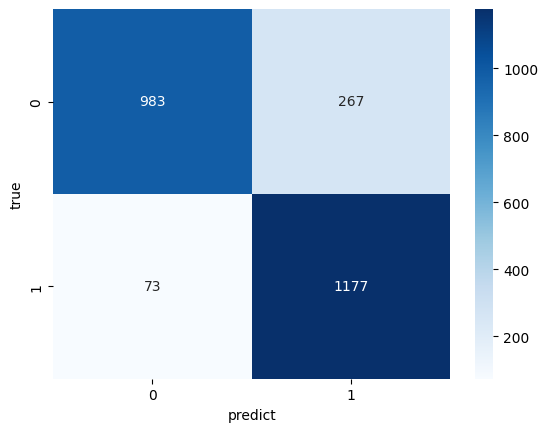

In [28]:
# print("开始验证/评估模型：")
from sklearn.metrics import confusion_matrix
import seaborn as sns
model = AlexNet(num_classes=2).to(device)
model.load_state_dict(torch.load("./model/model_best.pth"))
model.eval()
total = 0
correct = 0
predicted_labels = []
true_labels = []
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        predicted_labels.extend(predicted.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print(f"ACC {correct / total * 100}%")

# 生成混淆矩阵
conf = confusion_matrix(true_labels, predicted_labels)
# 可视化
sns.heatmap(conf, annot=True , fmt= "d" , cmap="Blues")
plt.xlabel("predict")
plt.ylabel("true")
plt.show()
